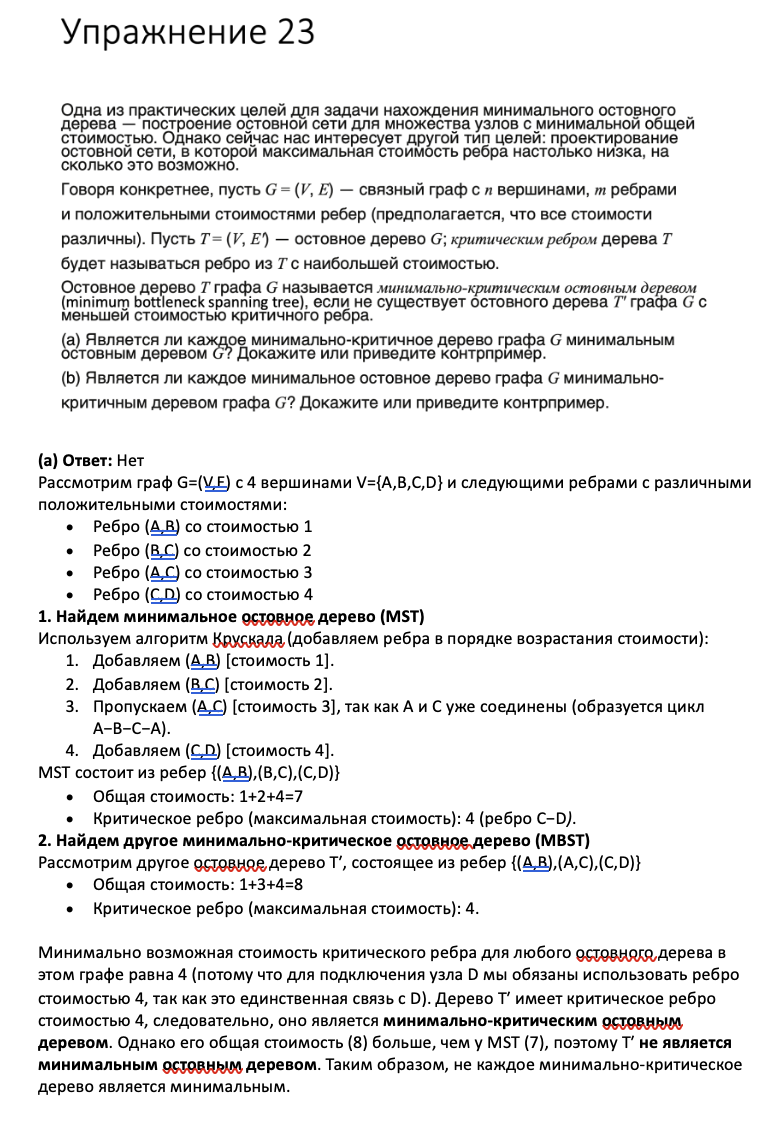

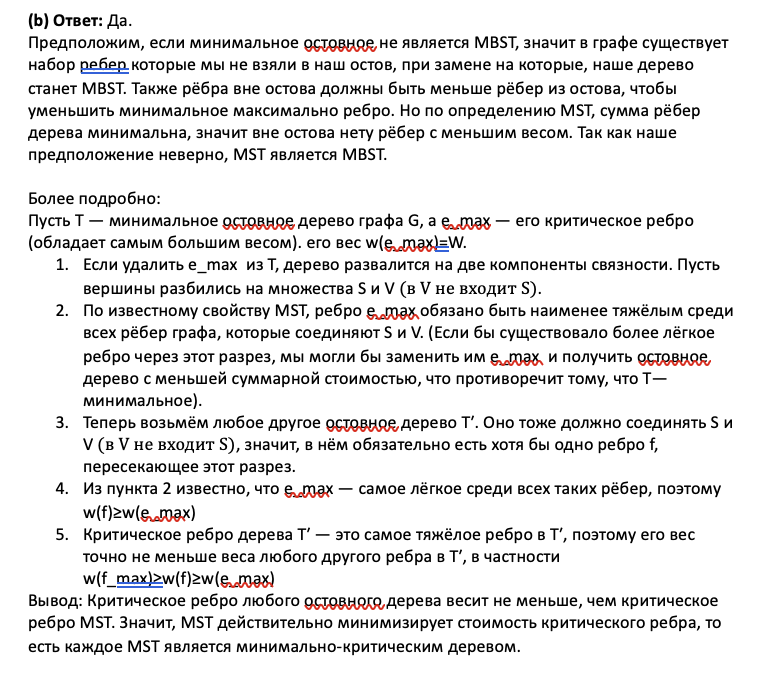

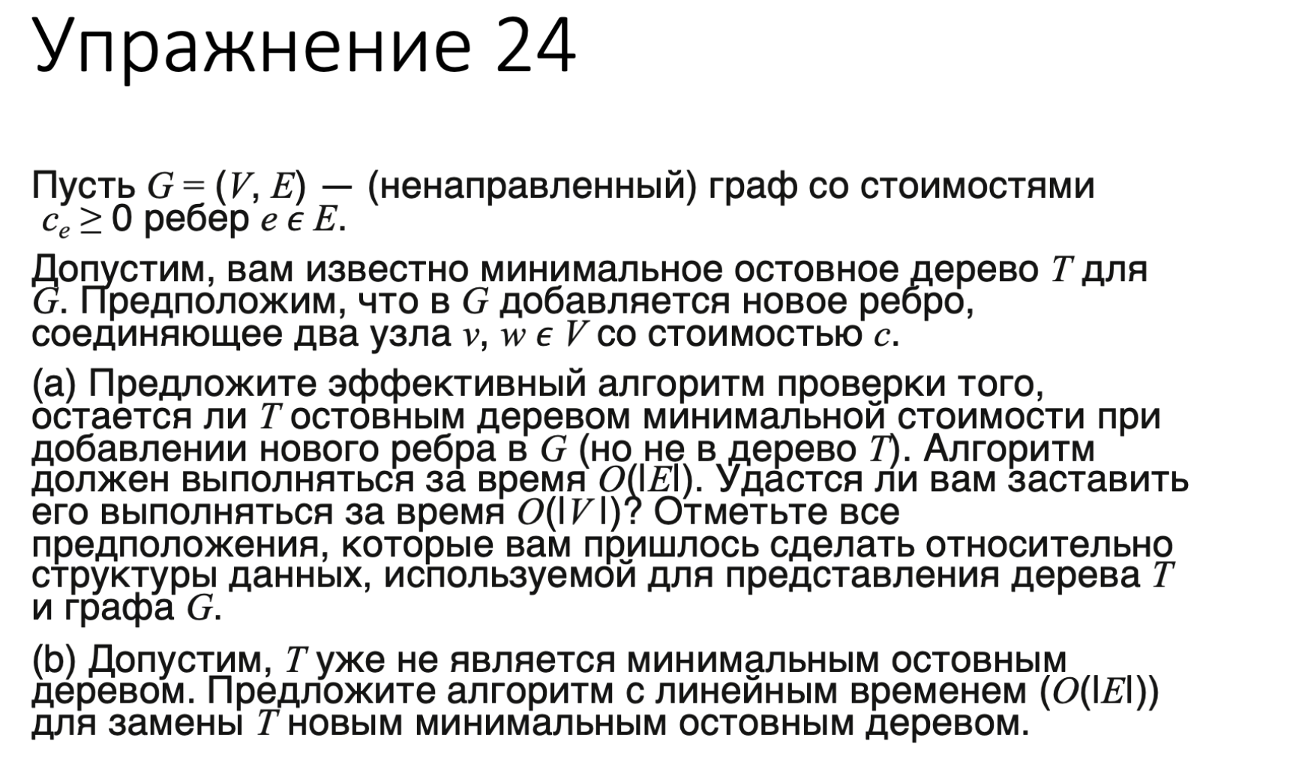

In [47]:
def find_path_max_edge(T_adj, v, w): # поиск макс ребра на уникальном пути от v до w
    parent = {}
    visited = set()
    def dfs(u, target):
        if u == target:
            return True
        visited.add(u)
        for neighbor, weight in T_adj[u]:
            if neighbor not in visited:
                parent[neighbor] = (u, weight)
                if dfs(neighbor, target):
                    return True
        return False
    dfs(v, w) # путь от w к v ищем максимум
    max_weight = 0
    max_edge = None
    current = w
    while current in parent:
        prev, weight = parent[current]
        if weight > max_weight:
            max_weight = weight
            max_edge = (prev, current)
        current = prev
    return max_edge, max_weight


def check_mst_is_still_valid(T_adj, v, w, c): # пункт а
    # Находим путь между v и w в дереве и максимальное ребро на нём
    max_edge, max_weight = find_path_max_edge(T_adj, v, w)
    print(f"Ребро ({v}, {w}) вес {c}; макс. ребро на пути {max_edge} вес {max_weight}")
    if c < max_weight:
        print(f"Результат: {c} < {max_weight}")
        return 'MST нарушено'
    else:
        print(f"Результат: {c} >= {max_weight}")
        return 'MST сохраняется'

In [48]:
def remove_edge(adj, u, v): # удаление ребра из списка смежности
    adj[u] = [(n, w) for n, w in adj[u] if n != v]
    adj[v] = [(n, w) for n, w in adj[v] if n != u]

def add_edge(adj, u, v, c): # добавление ребра в список смежности
    adj[u].append((v, c))
    adj[v].append((u, c))


def update_mst(T_adj, v, w, c): # проверка и обновление MST (пункт б)
    max_edge, max_weight = find_path_max_edge(T_adj, v, w)
    print(f"Максимальное ребро на {v} - {w}: {max_edge} (вес {max_weight})")
    if c < max_weight:
        print(f"Новое ребро ({v}, {w}, {c}) легче (T больше не MST)")
        print(f"Удаляем {max_edge}, добавляем ({v}, {w})")
        remove_edge(T_adj, max_edge[0], max_edge[1])
        add_edge(T_adj, v, w, c)
    else:
        print(f"Новое ребро ({v}, {w}, {c}) хуже (T остаётся MST)")
    return T_adj

In [49]:
T = {
    'A': [('B', 1)],
    'B': [('A', 1), ('C', 2)],
    'C': [('B', 2), ('D', 4)],
    'D': [('C', 4), ('E', 5)],
    'E': [('D', 5)]
}

print("Исходный")
for u in T:
    for v, w in T[u]:
        if u < v:
            print(f"({u}, {v}) = {w}")

max_edge, max_weight = find_path_max_edge(T, 'A', 'E')
print(f"\nМакс путь: max_edge={max_edge}, max_weight={max_weight}")

print(f'Пункт а: {check_mst_is_still_valid(T, 'A', 'C', 0.5)}')

print("\nДобавляем (A, C) с весом 0.5")
update_mst(T, 'A', 'C', 0.5)

print("\nДобавляем (B, D) с весом 10")
update_mst(T, 'B', 'D', 10)

print("\nДобавляем (D, E) с весом 4")
update_mst(T, 'D', 'E', 4)

max_edge, max_weight = find_path_max_edge(T, 'A', 'E')
print(f"\nРезультат: max_edge={max_edge}, max_weight={max_weight}")

print("\nИтог")
for u in T:
    for v, w in T[u]:
        if u < v:
            print(f"({u}, {v}) = {w}")

Исходный
(A, B) = 1
(B, C) = 2
(C, D) = 4
(D, E) = 5

Макс путь: max_edge=('D', 'E'), max_weight=5
Ребро (A, C) вес 0.5; макс. ребро на пути ('B', 'C') вес 2
Результат: 0.5 < 2
Пункт а: MST нарушено

Добавляем (A, C) с весом 0.5
Максимальное ребро на A - C: ('B', 'C') (вес 2)
Новое ребро (A, C, 0.5) легче (T больше не MST)
Удаляем ('B', 'C'), добавляем (A, C)

Добавляем (B, D) с весом 10
Максимальное ребро на B - D: ('C', 'D') (вес 4)
Новое ребро (B, D, 10) хуже (T остаётся MST)

Добавляем (D, E) с весом 4
Максимальное ребро на D - E: ('D', 'E') (вес 5)
Новое ребро (D, E, 4) легче (T больше не MST)
Удаляем ('D', 'E'), добавляем (D, E)

Результат: max_edge=('D', 'E'), max_weight=4

Итог
(A, B) = 1
(A, C) = 0.5
(C, D) = 4
(D, E) = 4


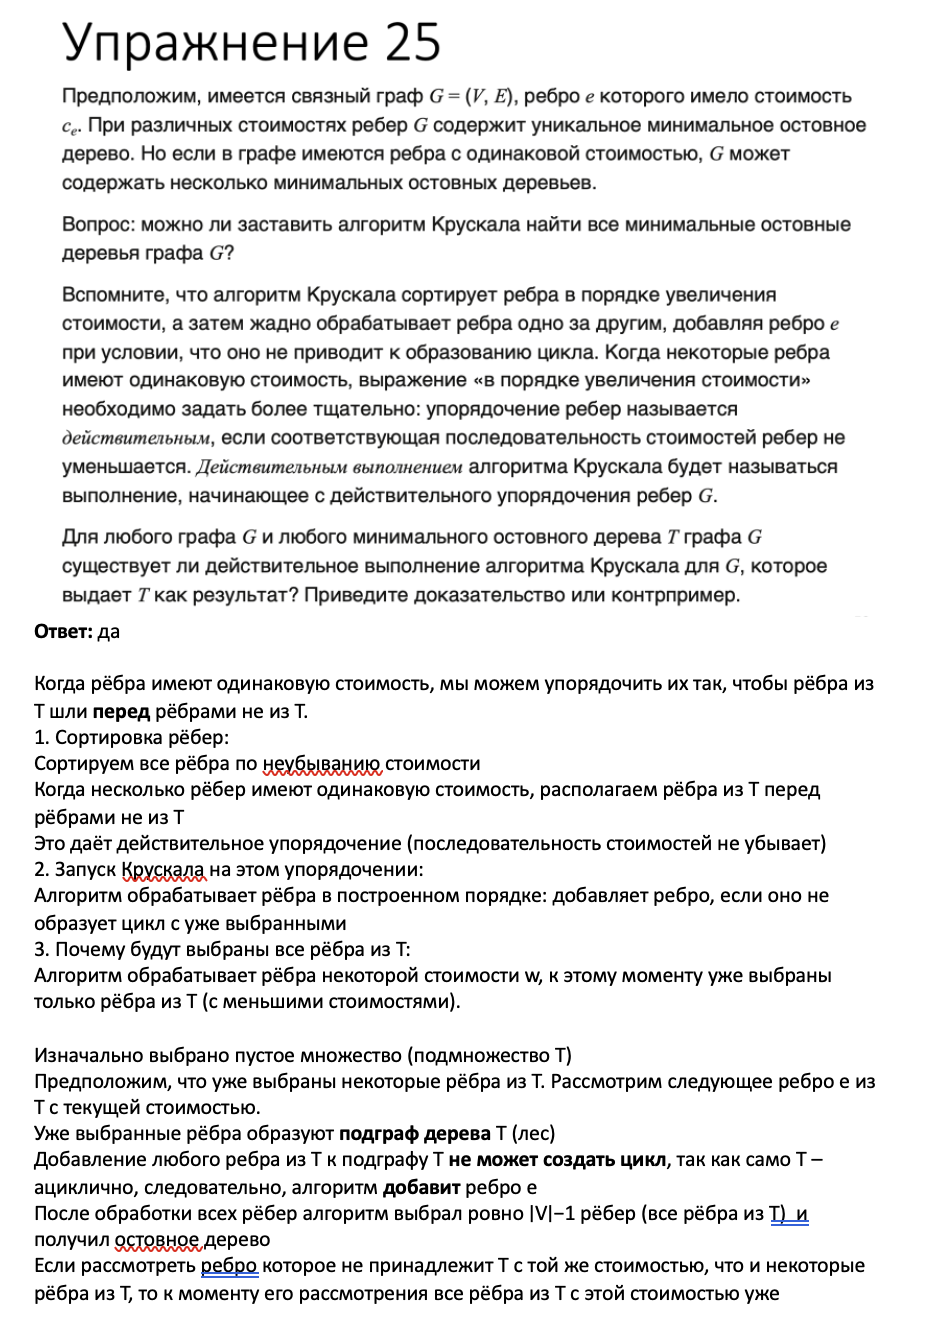

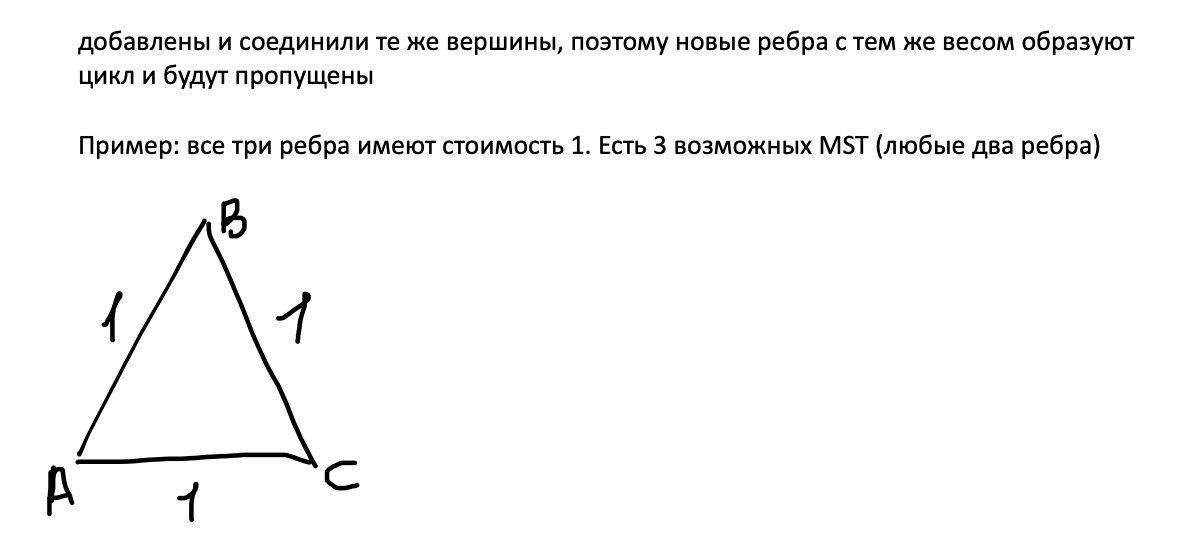